## Notebook 05c — VAR Model Estimation & Impulse Response Functions

Granger causality tells us *whether* commodity momentum predicts equity momentum. The VAR model tells us *how much* and *for how long*.

We estimate a bivariate VAR($p$) system for each hypothesised pair:

$$\mathbf{z}_t = \mathbf{c} + \sum_{k=1}^{p} \mathbf{A}_k \mathbf{z}_{t-k} + \boldsymbol{\varepsilon}_t$$

where $\mathbf{z}_t = [M_{X,t},\ M_{Y,t}]^\top$. The off-diagonal elements of $\mathbf{A}_k$ capture cross-asset predictability.

**Impulse Response Functions (IRFs)** trace how a one-standard-deviation shock to commodity momentum propagates into equity momentum over 10 trading days.

**Forecast Error Variance Decomposition (FEVD)** quantifies what fraction of equity momentum variance is explained by commodity momentum shocks vs its own history.

**Sections:**
1. Load data
2. VAR estimation — full sample
3. IRF — impulse response functions
4. FEVD — variance decomposition
5. Regime-split VAR (pre/post COVID)
6. Save outputs

---
### 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller
import warnings
import os
warnings.filterwarnings('ignore')

PROC_DIR = os.path.join("..", "data", "processed")
OUT_DIR  = os.path.join("..", "outputs")
FIG_DIR  = os.path.join("..", "figures")
os.makedirs(OUT_DIR, exist_ok=True)

PAIRS = [
    ("WTI",    "XLE"),
    ("Brent",  "XLE"),
    ("Copper", "XLB"),
    ("Gold",   "GDX"),
    ("NatGas", "XLE"),
]

# Strong pairs only for detailed VAR analysis
STRONG_PAIRS = [
    ("WTI",  "XLE"),
    ("Gold", "GDX"),
    ("Copper", "XLB"),
]

COLORS = {
    "WTI"   : "#e07b39",
    "Brent" : "#e0a039",
    "Copper": "#b5651d",
    "NatGas": "#6b8e23",
    "Gold"  : "#c5a028",
    "XLE"   : "#4a9eda",
    "XLB"   : "#6dbf6d",
    "GDX"   : "#c47fd4",
}

BREAK_COVID = pd.Timestamp("2020-03-01")
IRF_PERIODS = 10

# Load optimal lags
optimal_df = pd.read_csv(os.path.join(OUT_DIR, "optimal_lags.csv"))
optimal_lags = dict(zip(
    zip(optimal_df["Commodity"], optimal_df["Equity"]),
    zip(optimal_df["Optimal_Lag"], optimal_df["Optimal_Window"])
))

# Load momentum signals
momentum = {}
for w in [5, 10, 20]:
    momentum[w] = pd.read_csv(
        os.path.join(PROC_DIR, f"momentum_w{w}.csv"),
        index_col=0, parse_dates=True
    )

print("Data loaded.")
for (c, e), (lag, w) in optimal_lags.items():
    print(f"  {c}→{e} : optimal lag={lag}, window={w}")

Data loaded.
  WTI→XLE : optimal lag=4, window=20
  Brent→XLE : optimal lag=4, window=20
  Copper→XLB : optimal lag=5, window=20
  Gold→GDX : optimal lag=3, window=5
  NatGas→XLE : optimal lag=4, window=20


---
### 2. VAR Estimation — Full Sample

For each pair, we estimate a VAR($p$) where $p$ is selected by AIC. We report the coefficient matrix and key diagnostics.

In [2]:
var_models = {}
var_results_records = []

for comm, eq in PAIRS:
    lag, w = optimal_lags[(comm, eq)]
    lag, w = int(lag), int(w)

    data = momentum[w][[comm, eq]].dropna()

    # Fit VAR, select lag by AIC (cap at optimal lag + 2)
    model  = VAR(data)
    result = model.fit(maxlags=lag, ic='aic')
    var_models[(comm, eq)] = result

    # Extract cross-asset coefficient: commodity → equity at lag 1
    # In statsmodels VAR, coef matrix rows = equations, cols = lagged variables
    selected_lag = result.k_ar
    coef_matrix  = result.coefs  # shape (p, 2, 2)

    # [lag_idx, eq_idx, var_idx]: equity eq = index 1, commodity var = index 0
    cross_coef = coef_matrix[0, 1, 0]  # commodity → equity at lag 1
    aic_val    = result.aic

    var_results_records.append({
        "Pair"       : f"{comm}→{eq}",
        "Commodity"  : comm,
        "Equity"     : eq,
        "VAR_Lag"    : selected_lag,
        "Cross_Coef" : round(cross_coef, 6),
        "AIC"        : round(aic_val, 2),
        "Nobs"       : result.nobs,
    })

    print(f"\n{'='*55}")
    print(f"{comm} → {eq} | VAR({selected_lag}) | AIC={aic_val:.2f}")
    print(f"Cross-asset coef (commodity→equity, lag 1): {cross_coef:.6f}")
    print(result.summary())

var_summary_df = pd.DataFrame(var_results_records)


WTI → XLE | VAR(4) | AIC=-14.52
Cross-asset coef (commodity→equity, lag 1): 0.014577
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 07, Jun, 2026
Time:                     12:46:45
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -14.4937
Nobs:                     4099.00    HQIC:                  -14.5116
Log likelihood:           18147.3    FPE:                4.93637e-07
AIC:                     -14.5215    Det(Omega_mle):     4.91477e-07
--------------------------------------------------------------------
Results for equation WTI
            coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------
const         -0.000003         0.000556           -0.006           0.995
L1.WTI         0.880639         0.018684           47.134           0.000
L1.X

In [3]:
# Clean summary table
print("VAR MODEL SUMMARY")
print("=" * 60)
print(var_summary_df[["Pair", "VAR_Lag", "Cross_Coef", "AIC", "Nobs"]].to_string(index=False))

VAR MODEL SUMMARY
      Pair  VAR_Lag  Cross_Coef    AIC  Nobs
   WTI→XLE        4    0.014577 -14.52  4099
 Brent→XLE        4    0.019959 -14.85  4099
Copper→XLB        5    0.005415 -15.94  4098
  Gold→GDX        3   -0.015218 -16.07  4115
NatGas→XLE        4    0.006500 -13.37  4099


---
### 3. Impulse Response Functions

An IRF traces the response of equity momentum at time $t+h$ to a one-standard-deviation shock in commodity momentum at time $t$, holding all else constant.

We use **orthogonalised IRFs** (Cholesky decomposition) with commodity ordered first — consistent with our hypothesis that commodity momentum leads equity momentum.

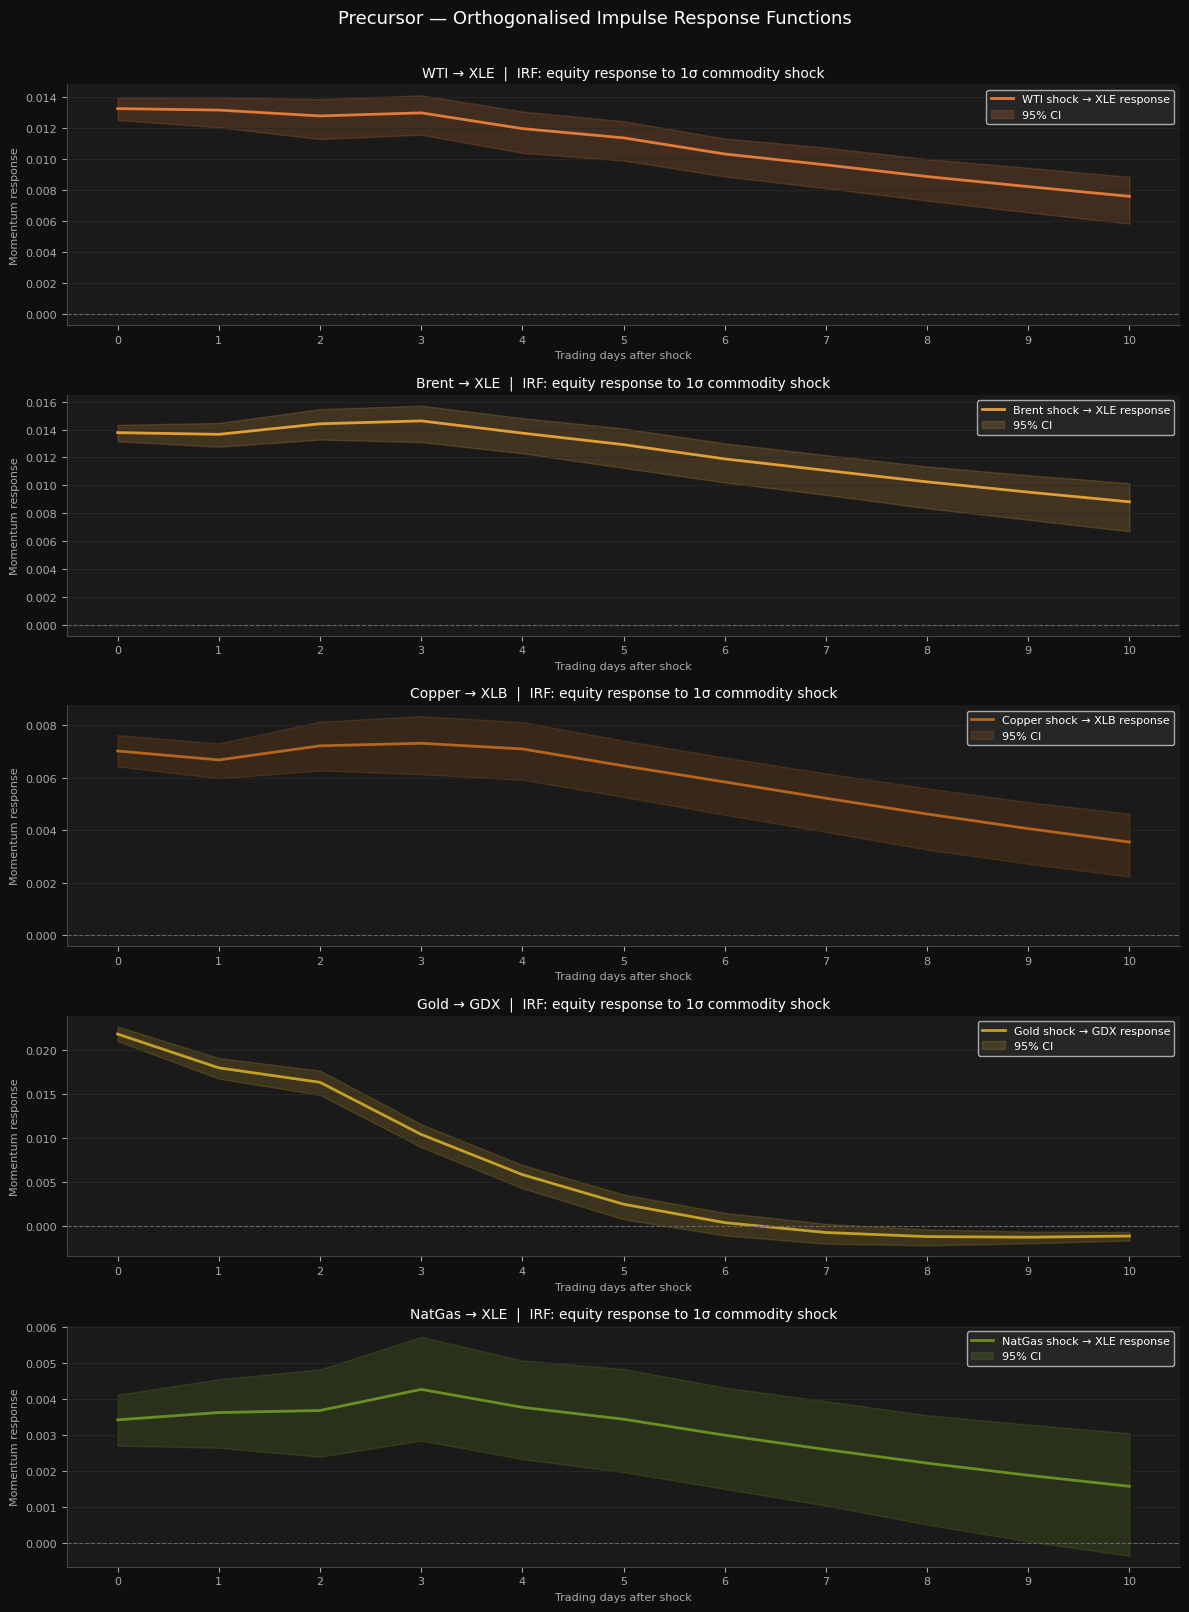

Saved: figures/05c_irf.png


In [6]:
fig, axes = plt.subplots(len(PAIRS), 1, figsize=(12, 16), facecolor="#0f0f0f")

irf_records = []

for i, (comm, eq) in enumerate(PAIRS):
    ax = axes[i]
    ax.set_facecolor("#1a1a1a")

    result = var_models[(comm, eq)]
    irf    = result.irf(IRF_PERIODS)

    # Orthogonalised IRF: response of eq (index 1) to shock in comm (index 0)
    irf_vals = irf.orth_irfs[:, 1, 0]

    # Confidence intervals via stderr_band
    irf_ci   = irf.errband_mc(orth=True, repl=200, signif=0.05)
    lower    = irf_ci[0][:, 1, 0]
    upper    = irf_ci[1][:, 1, 0]
    periods  = np.arange(len(irf_vals))

    ax.plot(periods, irf_vals, color=COLORS[comm], linewidth=2.0, label=f"{comm} shock → {eq} response")
    ax.fill_between(periods, lower, upper, color=COLORS[comm], alpha=0.2, label="95% CI")
    ax.axhline(0, color="#666666", linewidth=0.8, linestyle="--")

    ax.set_title(f"{comm} → {eq}  |  IRF: equity response to 1σ commodity shock",
                 color="white", fontsize=10, pad=6)
    ax.set_xlabel("Trading days after shock", color="#aaaaaa", fontsize=8)
    ax.set_ylabel("Momentum response", color="#aaaaaa", fontsize=8)
    ax.tick_params(colors="#aaaaaa", labelsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["bottom","left"]].set_color("#444444")
    ax.legend(facecolor="#2a2a2a", labelcolor="white", fontsize=8)
    ax.grid(axis="y", color="#2a2a2a", linewidth=0.5)
    ax.set_xticks(periods)

    for h, val in enumerate(irf_vals):
        irf_records.append({
            "Pair"    : f"{comm}→{eq}",
            "Horizon" : h,
            "IRF"     : round(val, 6),
            "Lower95" : round(lower[h], 6),
            "Upper95" : round(upper[h], 6),
            "Sig"     : not (lower[h] <= 0 <= upper[h])
        })

fig.suptitle("Precursor — Orthogonalised Impulse Response Functions",
             color="white", fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05c_irf.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/05c_irf.png")

irf_df = pd.DataFrame(irf_records)

In [7]:
# Print IRF summary: peak response and when it crosses zero
print("IRF SUMMARY — Peak response and persistence")
print("=" * 60)
for comm, eq in PAIRS:
    pair_irf = irf_df[irf_df["Pair"] == f"{comm}→{eq}"]
    peak_row = pair_irf.loc[pair_irf["IRF"].abs().idxmax()]
    sig_horizons = pair_irf[pair_irf["Sig"]]["Horizon"].tolist()
    print(f"{comm}→{eq}: peak={peak_row['IRF']:.4f} at h={int(peak_row['Horizon'])} | sig horizons={sig_horizons}")

IRF SUMMARY — Peak response and persistence
WTI→XLE: peak=0.0133 at h=0 | sig horizons=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Brent→XLE: peak=0.0146 at h=3 | sig horizons=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Copper→XLB: peak=0.0073 at h=3 | sig horizons=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Gold→GDX: peak=0.0218 at h=0 | sig horizons=[0, 1, 2, 3, 4, 5, 8, 9, 10]
NatGas→XLE: peak=0.0043 at h=3 | sig horizons=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


---
### 4. Forecast Error Variance Decomposition (FEVD)

FEVD answers: at forecast horizon $h$, what fraction of the variance in equity momentum is attributable to shocks in commodity momentum (vs its own past)?

A high commodity share at short horizons (h=1–5) confirms that commodity momentum is a meaningful driver of equity momentum dynamics.

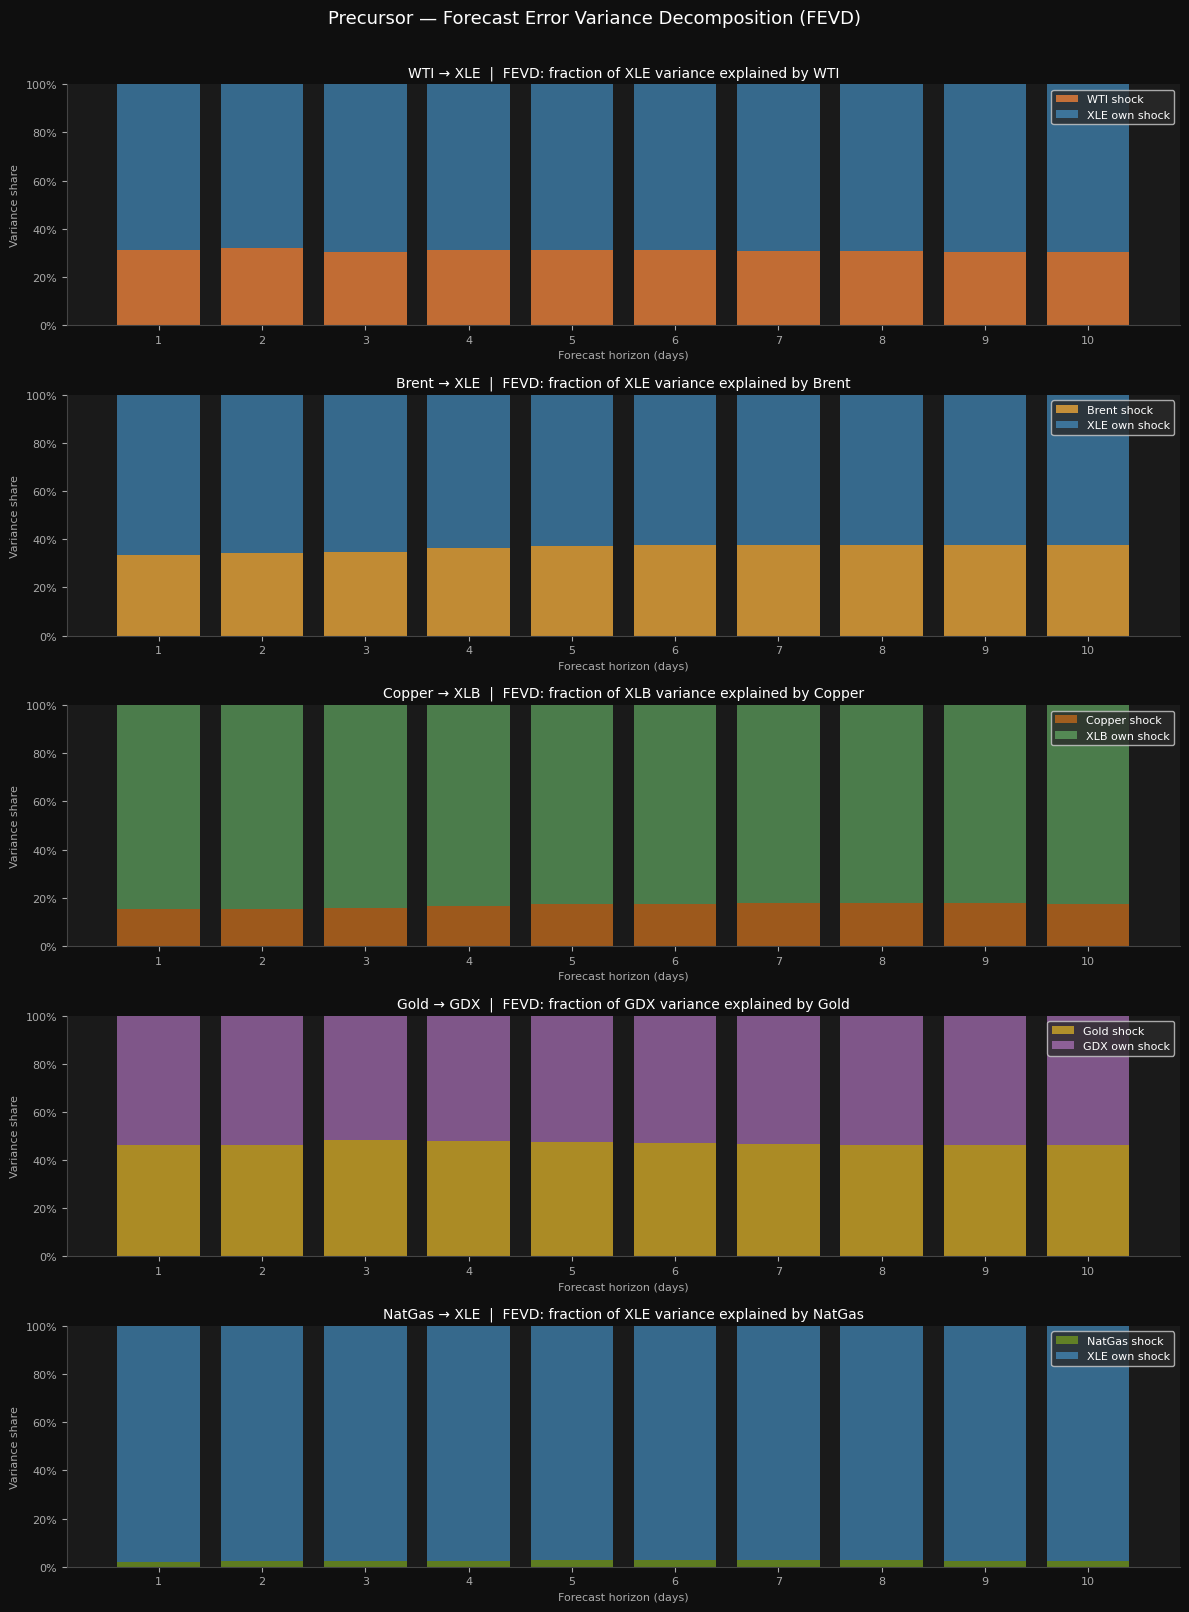

Saved: figures/05c_fevd.png


In [9]:
fig, axes = plt.subplots(len(PAIRS), 1, figsize=(12, 16), facecolor="#0f0f0f")

fevd_records = []

for i, (comm, eq) in enumerate(PAIRS):
    ax = axes[i]
    ax.set_facecolor("#1a1a1a")

    result = var_models[(comm, eq)]
    fevd   = result.fevd(IRF_PERIODS)

    # FEVD for equity equation (index 1)
    # fevd.decomp shape: (neqs, periods, neqs)
    # [eq_idx, h, shock_idx]
    eq_fevd   = fevd.decomp[1, :, :]  # shape (periods, 2)
    own_share  = eq_fevd[:, 1]         # equity's own shock
    comm_share = eq_fevd[:, 0]         # commodity shock contribution
    horizons   = np.arange(1, eq_fevd.shape[0] + 1)

    ax.bar(horizons, comm_share, color=COLORS[comm], alpha=0.85, label=f"{comm} shock")
    ax.bar(horizons, own_share,  bottom=comm_share,  color=COLORS[eq],   alpha=0.6,  label=f"{eq} own shock")

    ax.set_title(f"{comm} → {eq}  |  FEVD: fraction of {eq} variance explained by {comm}",
                 color="white", fontsize=10, pad=6)
    ax.set_xlabel("Forecast horizon (days)", color="#aaaaaa", fontsize=8)
    ax.set_ylabel("Variance share", color="#aaaaaa", fontsize=8)
    ax.tick_params(colors="#aaaaaa", labelsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["bottom","left"]].set_color("#444444")
    ax.legend(facecolor="#2a2a2a", labelcolor="white", fontsize=8)
    ax.set_xticks(horizons)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_ylim(0, 1)

    for h_idx, h in enumerate(horizons):
        fevd_records.append({
            "Pair"        : f"{comm}→{eq}",
            "Horizon"     : h,
            "Comm_Share"  : round(comm_share[h_idx], 4),
            "Own_Share"   : round(own_share[h_idx],  4),
        })

fig.suptitle("Precursor — Forecast Error Variance Decomposition (FEVD)",
             color="white", fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05c_fevd.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/05c_fevd.png")

fevd_df = pd.DataFrame(fevd_records)

In [10]:
# FEVD summary at h=1 and h=5
print("FEVD SUMMARY — Commodity shock share of equity variance")
print("=" * 55)
print(f"{'Pair':<15} {'h=1':>8} {'h=3':>8} {'h=5':>8} {'h=10':>8}")
print("-" * 55)
for comm, eq in PAIRS:
    pair_fevd = fevd_df[fevd_df["Pair"] == f"{comm}→{eq}"]
    vals = {}
    for h in [1, 3, 5, 10]:
        row = pair_fevd[pair_fevd["Horizon"] == h]
        vals[h] = row["Comm_Share"].values[0] if not row.empty else np.nan
    print(f"{comm}→{eq:<10} {vals[1]:>8.1%} {vals[3]:>8.1%} {vals[5]:>8.1%} {vals[10]:>8.1%}")

FEVD SUMMARY — Commodity shock share of equity variance
Pair                 h=1      h=3      h=5     h=10
-------------------------------------------------------
WTI→XLE           31.1%    30.3%    31.0%    30.2%
Brent→XLE           33.4%    34.7%    37.1%    37.5%
Copper→XLB           15.3%    15.7%    17.2%    17.5%
Gold→GDX           46.4%    48.4%    47.4%    46.4%
NatGas→XLE            2.1%     2.3%     2.7%     2.5%


---
### 5. Regime-Split VAR — Pre vs Post COVID

Given the structural breaks identified in notebook 05b, we estimate separate VAR models for pre and post COVID subsamples and compare the cross-asset coefficient magnitude.

In [11]:
print("REGIME-SPLIT VAR — Cross-asset coefficient (commodity→equity, lag 1)")
print("=" * 68)
print(f"{'Pair':<15} {'Full':>10} {'Pre-COVID':>12} {'Post-COVID':>12} {'Change':>10}")
print("-" * 68)

regime_records = []

for comm, eq in PAIRS:
    lag, w = optimal_lags[(comm, eq)]
    lag, w = int(lag), int(w)
    data   = momentum[w][[comm, eq]].dropna()

    def fit_var_coef(df, max_lag):
        if len(df) < max_lag * 5:
            return np.nan
        try:
            res = VAR(df).fit(maxlags=max_lag, ic='aic')
            return res.coefs[0, 1, 0]  # commodity→equity at lag 1
        except Exception:
            return np.nan

    coef_full = fit_var_coef(data, lag)
    coef_pre  = fit_var_coef(data[data.index <  BREAK_COVID], lag)
    coef_post = fit_var_coef(data[data.index >= BREAK_COVID], lag)

    change = "↑ stronger" if abs(coef_post) > abs(coef_pre) else "↓ weaker"
    print(f"{comm}→{eq:<10} {coef_full:>10.4f} {coef_pre:>12.4f} {coef_post:>12.4f} {change:>10}")

    regime_records.append({
        "Pair"      : f"{comm}→{eq}",
        "Coef_Full" : round(coef_full, 6),
        "Coef_Pre"  : round(coef_pre,  6),
        "Coef_Post" : round(coef_post, 6),
        "Strengthened": abs(coef_post) > abs(coef_pre)
    })

regime_df = pd.DataFrame(regime_records)

REGIME-SPLIT VAR — Cross-asset coefficient (commodity→equity, lag 1)
Pair                  Full    Pre-COVID   Post-COVID     Change
--------------------------------------------------------------------
WTI→XLE            0.0146      -0.0224       0.0325 ↑ stronger
Brent→XLE            0.0200      -0.0295       0.0574 ↑ stronger
Copper→XLB            0.0054       0.0030      -0.0033 ↑ stronger
Gold→GDX           -0.0152      -0.0662       0.0443   ↓ weaker
NatGas→XLE            0.0065      -0.0016       0.0109 ↑ stronger


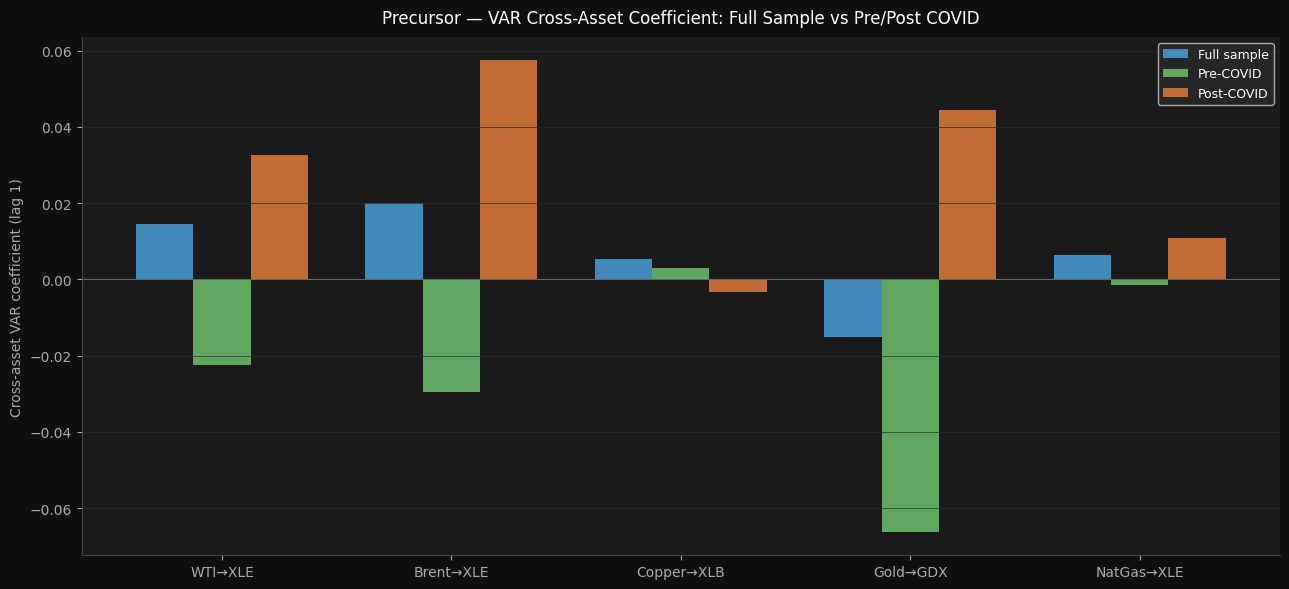

Saved: figures/05c_regime_coefs.png


In [12]:
# Visualise regime-split coefficients
pair_labels = [f"{c}→{e}" for c, e in PAIRS]
x_pos = np.arange(len(PAIRS))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6), facecolor="#0f0f0f")
ax.set_facecolor("#1a1a1a")

ax.bar(x_pos - width, regime_df["Coef_Full"], width, label="Full sample",  color="#4a9eda", alpha=0.85)
ax.bar(x_pos,         regime_df["Coef_Pre"],  width, label="Pre-COVID",    color="#6dbf6d", alpha=0.85)
ax.bar(x_pos + width, regime_df["Coef_Post"], width, label="Post-COVID",   color="#e07b39", alpha=0.85)

ax.axhline(0, color="#666666", linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(pair_labels, color="white", fontsize=10)
ax.set_ylabel("Cross-asset VAR coefficient (lag 1)", color="#aaaaaa")
ax.tick_params(colors="#aaaaaa")
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("#444444")
ax.legend(facecolor="#2a2a2a", labelcolor="white", fontsize=9)
ax.set_title("Precursor — VAR Cross-Asset Coefficient: Full Sample vs Pre/Post COVID",
             color="white", fontsize=12, pad=10)
ax.grid(axis="y", color="#2a2a2a", linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05c_regime_coefs.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/05c_regime_coefs.png")

---
### 6. Save Outputs

In [13]:
# VAR summary
var_summary_df.to_csv(os.path.join(OUT_DIR, "var_summary.csv"), index=False)
print(f"Saved: outputs/var_summary.csv")

# IRF values
irf_df.to_csv(os.path.join(OUT_DIR, "irf_results.csv"), index=False)
print(f"Saved: outputs/irf_results.csv")

# FEVD values
fevd_df.to_csv(os.path.join(OUT_DIR, "fevd_results.csv"), index=False)
print(f"Saved: outputs/fevd_results.csv")

# Regime coefficients
regime_df.to_csv(os.path.join(OUT_DIR, "regime_var_coefs.csv"), index=False)
print(f"Saved: outputs/regime_var_coefs.csv")

Saved: outputs/var_summary.csv
Saved: outputs/irf_results.csv
Saved: outputs/fevd_results.csv
Saved: outputs/regime_var_coefs.csv


---
### 7. Summary

| Output | Path |
|---|---|
| VAR model summary | `outputs/var_summary.csv` |
| IRF values | `outputs/irf_results.csv` |
| FEVD values | `outputs/fevd_results.csv` |
| Regime VAR coefficients | `outputs/regime_var_coefs.csv` |
| IRF plot | `figures/05c_irf.png` |
| FEVD plot | `figures/05c_fevd.png` |
| Regime coefficient plot | `figures/05c_regime_coefs.png` |

**What to look for:**
- IRF significant at h=1–3 → fast spillover, short-lived
- IRF significant at h=5+ → persistent transmission, potentially exploitable
- FEVD commodity share > 10% at h=1 → commodity is a meaningful driver, not noise
- Post-COVID coefficient stronger than pre → the 2020 structural break *intensified* the spillover relationship for some pairs